In [ ]:
# Install required libraries
!pip install pandas numpy matplotlib seaborn scikit-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_style("whitegrid")

In [ ]:
df = pd.read_csv("customer_churn (2).csv")
df.head()

,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


In [ ]:
print("Dataset Shape:", df.shape)

Dataset Shape: (500, 9)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   CustomerID        500 non-null    object
 1   Tenure            500 non-null    int64 
 2   MonthlyCharges    500 non-null    int64 
 3   TotalCharges      500 non-null    int64 
 4   Contract          500 non-null    object
 5   PaymentMethod     500 non-null    object
 6   PaperlessBilling  500 non-null    object
 7   SeniorCitizen     500 non-null    int64 
 8   Churn             500 non-null    int64 
dtypes: int64(5), object(4)
memory usage: 35.3+ KB


In [ ]:
df.describe()

,Tenure,MonthlyCharges,TotalCharges,SeniorCitizen,Churn
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,36.532000,113.636000,4237.882000,0.498000,0.106000
std,20.667057,51.799903,2260.619837,0.500497,0.308146
min,1.000000,20.000000,159.000000,0.000000,0.000000
25%,19.000000,67.000000,2237.250000,0.000000,0.000000
50%,37.000000,115.000000,4182.500000,0.000000,0.000000
75%,54.000000,158.000000,6266.750000,1.000000,0.000000
max,71.000000,199.000000,7992.000000,1.000000,1.000000


In [ ]:
df.isnull().sum()

,0
CustomerID,0
Tenure,0
MonthlyCharges,0
TotalCharges,0
Contract,0
PaymentMethod,0
PaperlessBilling,0
SeniorCitizen,0
Churn,0


In [ ]:
label_encoder = LabelEncoder()

categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

df.head()

,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,0,6,64,1540,1,1,0,1,0
1,1,21,113,1753,0,2,1,1,0
2,2,27,31,1455,2,1,0,1,0
3,3,53,29,7150,0,2,0,1,0
4,4,16,185,1023,1,2,0,1,0


In [ ]:
df.to_csv("raw_data.csv", index=False)

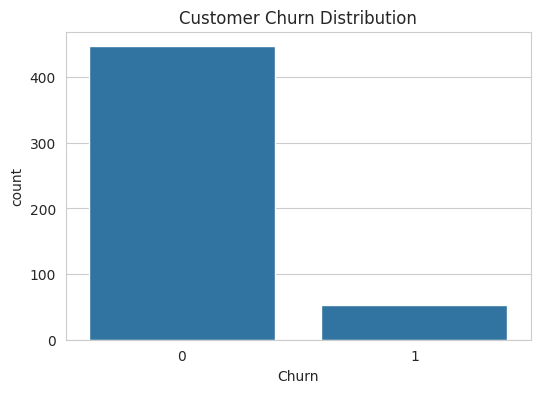

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)

plt.title("Customer Churn Distribution")
plt.show()

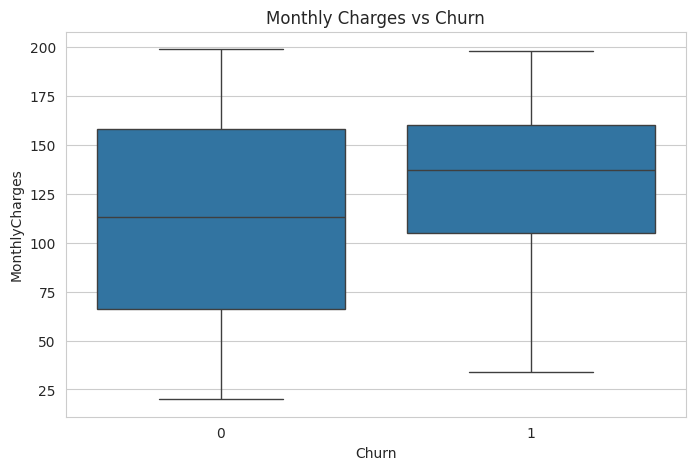

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

plt.title("Monthly Charges vs Churn")
plt.show()

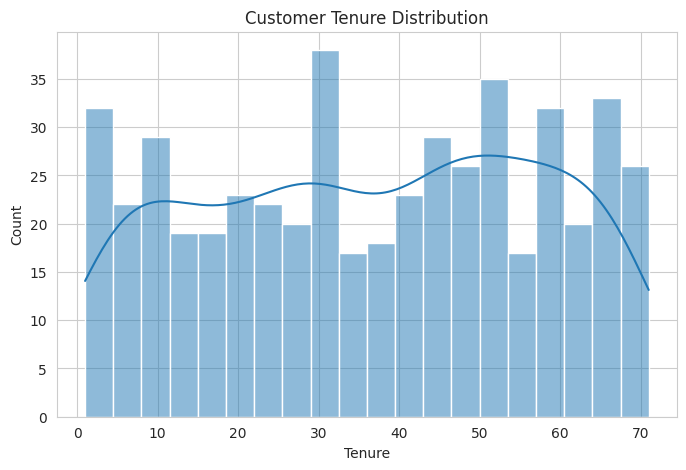

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Tenure'], bins=20, kde=True)

plt.title("Customer Tenure Distribution")
plt.show()

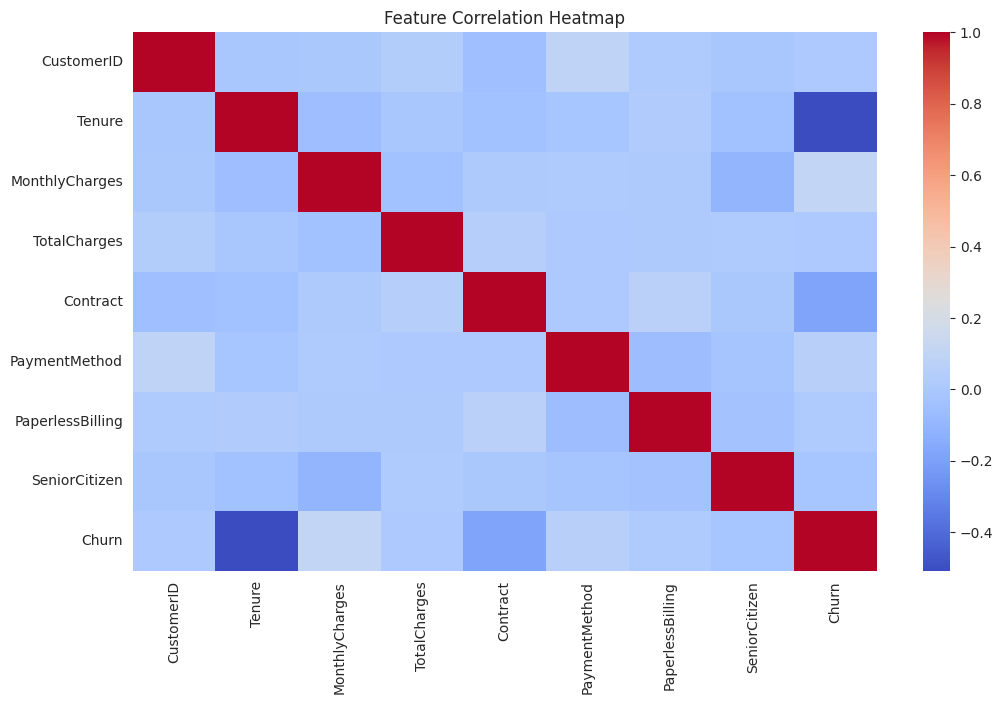

In [ ]:
plt.figure(figsize=(12,7))
sns.heatmap(df.corr(), cmap='coolwarm')

plt.title("Feature Correlation Heatmap")
plt.show()

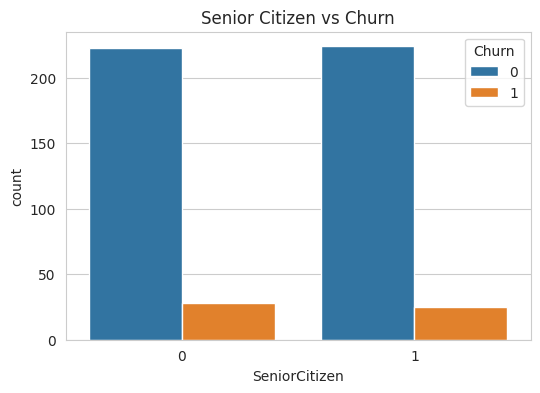

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='SeniorCitizen', hue='Churn', data=df)

plt.title("Senior Citizen vs Churn")
plt.show()

In [ ]:
X = df.drop(['CustomerID','Churn'], axis=1)
y = df['Churn']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.95


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.96      0.97        84
           1       0.82      0.88      0.85        16

    accuracy                           0.95       100
   macro avg       0.90      0.92      0.91       100
weighted avg       0.95      0.95      0.95       100



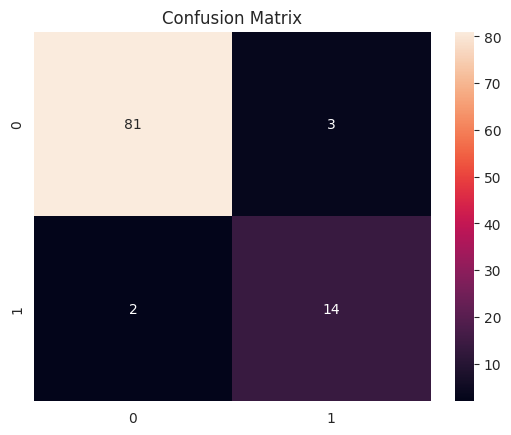

In [ ]:
  sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')

plt.title("Confusion Matrix")
plt.show()

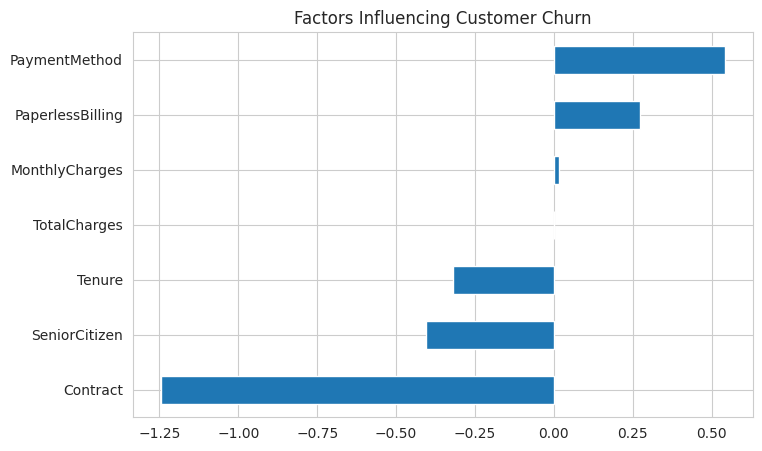

In [ ]:
importance = pd.Series(model.coef_[0], index=X.columns)

importance.sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.title("Factors Influencing Customer Churn")
plt.show()

In [ ]:
df.to_csv("cleaned_data.csv", index=False)